### Setup & Imports

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import pickle
from datetime import datetime
import warnings

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, precision_recall_curve, auc,
    roc_curve, precision_score, recall_score, f1_score
)
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

### Load Prepared Data

In [16]:
# Load NumPy arrays (faster)
X_train = np.load('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/X_train.npy')
X_val = np.load('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/X_val.npy')
X_test = np.load('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/X_test.npy')

y_train = np.load('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/y_train.npy')
y_val = np.load('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/y_val.npy')
y_test = np.load('C:/Users/parth/Market-Anomaly-Detection-System/data/processed/y_test.npy')

In [17]:
print(f"✓ Data loaded successfully!")
print(f"\n📊 Dataset Shapes:")
print(f"   • X_train: {X_train.shape}")
print(f"   • X_val:   {X_val.shape}")
print(f"   • X_test:  {X_test.shape}")
print(f"   • y_train: {y_train.shape}")
print(f"   • y_val:   {y_val.shape}")
print(f"   • y_test:  {y_test.shape}")

✓ Data loaded successfully!

📊 Dataset Shapes:
   • X_train: (198608, 68)
   • X_val:   (42558, 68)
   • X_test:  (42560, 68)
   • y_train: (198608,)
   • y_val:   (42558,)
   • y_test:  (42560,)


In [18]:
print(f"\n⚖️  Class Distribution:")
print(f"   • Train frauds: {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"   • Val frauds:   {y_val.sum():,} ({y_val.mean()*100:.3f}%)")
print(f"   • Test frauds:  {y_test.sum():,} ({y_test.mean()*100:.3f}%)")


⚖️  Class Distribution:
   • Train frauds: 350 (0.176%)
   • Val frauds:   57 (0.134%)
   • Test frauds:  66 (0.155%)


### MODEL 1 - Isolation Forest (PRIMARY)

In [19]:
# Initialize Isolation Forest
contamination = y_train.mean()  # Expected fraud rate
print(f"📊 Configuration:")
print(f"   • Contamination: {contamination:.4f} ({contamination*100:.2f}%)")
print(f"   • n_estimators: 100")
print(f"   • max_samples: 256")
print(f"   • random_state: 42")

📊 Configuration:
   • Contamination: 0.0018 (0.18%)
   • n_estimators: 100
   • max_samples: 256
   • random_state: 42


In [20]:
iso_forest = IsolationForest(
    contamination=contamination,
    n_estimators=100,
    max_samples=256,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

In [21]:
# Train on training data
print(f"\n⏳ Training Isolation Forest...")
iso_forest.fit(X_train)
print(f"✓ Training complete!")


⏳ Training Isolation Forest...
✓ Training complete!


In [22]:
# Get anomaly scores (lower = more anomalous)
print(f"\n📊 Generating Anomaly Scores...")
train_scores = iso_forest.score_samples(X_train)
val_scores = iso_forest.score_samples(X_val)
test_scores = iso_forest.score_samples(X_test)


📊 Generating Anomaly Scores...


In [23]:
# Normalize scores to 0-1 (higher = more anomalous)
def normalize_scores(scores):
    min_score = scores.min()
    max_score = scores.max()
    normalized = (scores - min_score) / (max_score - min_score)
    return 1 - normalized  # Invert so higher = more anomalous

train_scores_norm = normalize_scores(train_scores)
val_scores_norm = normalize_scores(val_scores)
test_scores_norm = normalize_scores(test_scores)

print(f"✓ Anomaly scores generated")
print(f"   • Score range: 0 (normal) to 1 (anomalous)")

✓ Anomaly scores generated
   • Score range: 0 (normal) to 1 (anomalous)


### Isolation Forest - Threshold Tuning

In [24]:
# Try different thresholds on validation set
thresholds = np.arange(0.5, 1.0, 0.05)
threshold_results = []

In [25]:
for threshold in thresholds:
    # Predict
    val_pred = (val_scores_norm >= threshold).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_val, val_pred, zero_division=0)
    recall = recall_score(y_val, val_pred, zero_division=0)
    f1 = f1_score(y_val, val_pred, zero_division=0)
    
    # False positive rate
    tn = ((val_pred == 0) & (y_val == 0)).sum()
    fp = ((val_pred == 1) & (y_val == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    
    threshold_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'fpr': fpr
    })

results_df = pd.DataFrame(threshold_results)

print("📊 Threshold Analysis:")
display(results_df.round(4))

📊 Threshold Analysis:


,threshold,precision,recall,f1,fpr
0,0.50,0.0152,0.2456,0.0286,0.0214
1,0.55,0.0194,0.2105,0.0355,0.0143
2,0.60,0.0189,0.1404,0.0333,0.0098
3,0.65,0.0160,0.0877,0.0270,0.0072
4,0.70,0.0092,0.0351,0.0146,0.0051
5,0.75,0.0072,0.0175,0.0103,0.0032
6,0.80,0.0000,0.0000,0.0000,0.0018
7,0.85,0.0000,0.0000,0.0000,0.0011
8,0.90,0.0000,0.0000,0.0000,0.0005
9,0.95,0.0000,0.0000,0.0000,0.0001


In [26]:
# Find best threshold (maximize F1)

best_idx = results_df['f1'].idxmax()
best_threshold = results_df.loc[best_idx, 'threshold']
best_f1 = results_df.loc[best_idx, 'f1']

In [27]:
print(f"\n✓ Best Threshold: {best_threshold:.2f}")
print(f"   • F1-Score: {best_f1:.4f}")
print(f"   • Precision: {results_df.loc[best_idx, 'precision']:.4f}")
print(f"   • Recall: {results_df.loc[best_idx, 'recall']:.4f}")
print(f"   • FPR: {results_df.loc[best_idx, 'fpr']:.4f}")


✓ Best Threshold: 0.55
   • F1-Score: 0.0355
   • Precision: 0.0194
   • Recall: 0.2105
   • FPR: 0.0143


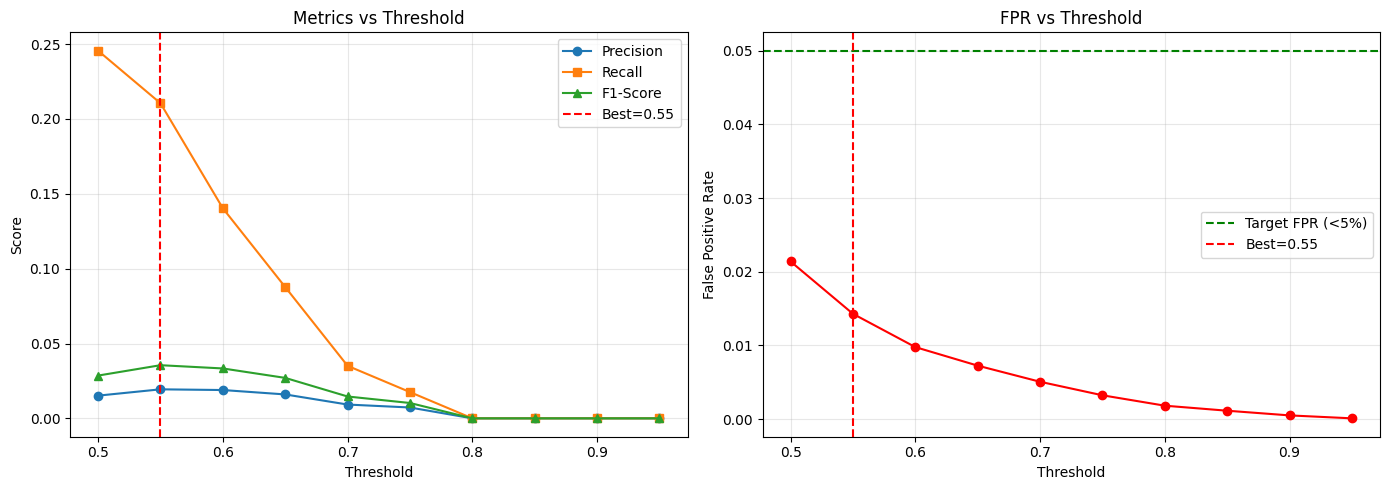

In [28]:
# Visualize threshold tuning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Metrics vs threshold
axes[0].plot(results_df['threshold'], results_df['precision'], marker='o', label='Precision')
axes[0].plot(results_df['threshold'], results_df['recall'], marker='s', label='Recall')
axes[0].plot(results_df['threshold'], results_df['f1'], marker='^', label='F1-Score')
axes[0].axvline(best_threshold, color='red', linestyle='--', label=f'Best={best_threshold:.2f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# FPR vs threshold
axes[1].plot(results_df['threshold'], results_df['fpr'], marker='o', color='red')
axes[1].axhline(0.05, color='green', linestyle='--', label='Target FPR (<5%)')
axes[1].axvline(best_threshold, color='red', linestyle='--', label=f'Best={best_threshold:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('False Positive Rate')
axes[1].set_title('FPR vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Isolation Forest - Evaluation on Test Set

In [29]:
# Predict on test set with best threshold
test_pred_iso = (test_scores_norm >= best_threshold).astype(int)

In [30]:
# Classification report
print("\n📋 Classification Report:")
print(classification_report(y_test, test_pred_iso, 
                          target_names=['Legitimate', 'Fraud']))


📋 Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     42494
       Fraud       0.02      0.23      0.03        66

    accuracy                           0.98     42560
   macro avg       0.51      0.60      0.51     42560
weighted avg       1.00      0.98      0.99     42560



In [31]:
# Confusion matrix
cm = confusion_matrix(y_test, test_pred_iso)
tn, fp, fn, tp = cm.ravel()

print(f"\n📊 Confusion Matrix:")
print(f"                Predicted")
print(f"                Legit  Fraud")
print(f"Actual Legit    {tn:5d}  {fp:5d}")
print(f"       Fraud    {fn:5d}  {tp:5d}")


📊 Confusion Matrix:
                Predicted
                Legit  Fraud
Actual Legit    41654    840
       Fraud       51     15


In [32]:
# Calculate key metrics
detection_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * precision * detection_rate / (precision + detection_rate) if (precision + detection_rate) > 0 else 0

print(f"\n🎯 Key Metrics:")
print(f"   • Detection Rate (Recall): {detection_rate*100:.2f}% {'✓' if detection_rate >= 0.85 else '✗'} (Target: >85%)")
print(f"   • False Positive Rate:     {fpr*100:.2f}% {'✓' if fpr <= 0.05 else '✗'} (Target: <5%)")
print(f"   • Precision:               {precision*100:.2f}%")
print(f"   • F1-Score:                {f1:.4f}")


🎯 Key Metrics:
   • Detection Rate (Recall): 22.73% ✗ (Target: >85%)
   • False Positive Rate:     1.98% ✓ (Target: <5%)
   • Precision:               1.75%
   • F1-Score:                0.0326


In [34]:
# ROC-AUC
roc_auc = roc_auc_score(y_test, test_scores_norm)
print(f"   • ROC-AUC: {roc_auc:.4f}")

# PR-AUC (better for imbalanced data)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_scores_norm)
pr_auc = auc(recall_curve, precision_curve)
print(f"   • PR-AUC: {pr_auc:.4f}")

   • ROC-AUC: 0.8915
   • PR-AUC: 0.0138


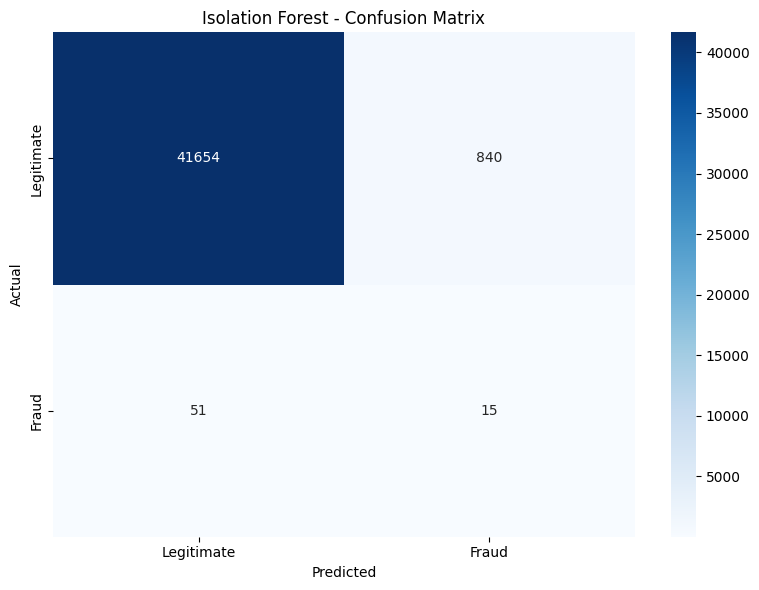

In [37]:
# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Isolation Forest - Confusion Matrix')
plt.tight_layout()
plt.savefig('C:/Users/parth/Market-Anomaly-Detection-System/reports/figures/isolation_forest_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### MODEL 2 - Statistical Z-Score Detection

In [38]:
# Calculate Z-scores for each feature
print("⏳ Calculating Z-scores...")

# Fit on training data
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

⏳ Calculating Z-scores...


In [39]:
# Calculate Z-scores for all sets
def calculate_z_scores(X, mean, std):
    z_scores = np.abs((X - mean) / (std + 1e-10))
    # Max Z-score across features (most anomalous feature)
    max_z = z_scores.max(axis=1)
    return max_z

In [40]:
train_z_scores = calculate_z_scores(X_train, train_mean, train_std)
val_z_scores = calculate_z_scores(X_val, train_mean, train_std)
test_z_scores = calculate_z_scores(X_test, train_mean, train_std)

In [41]:
# Normalize to 0-1 for consistency
def normalize_z_scores(z_scores):
    return z_scores / (z_scores.max() + 1e-10)

train_z_norm = normalize_z_scores(train_z_scores)
val_z_norm = normalize_z_scores(val_z_scores)
test_z_norm = normalize_z_scores(test_z_scores)

print("✓ Z-scores calculated")

✓ Z-scores calculated


In [42]:
# Tune threshold on validation set
z_thresholds = np.arange(0.3, 0.9, 0.05)
z_results = []


for threshold in z_thresholds:
    val_pred = (val_z_norm >= threshold).astype(int)
    precision = precision_score(y_val, val_pred, zero_division=0)
    recall = recall_score(y_val, val_pred, zero_division=0)
    f1 = f1_score(y_val, val_pred, zero_division=0)
    
    z_results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

z_results_df = pd.DataFrame(z_results)

In [43]:
# Find best threshold
best_z_idx = z_results_df['f1'].idxmax()
best_z_threshold = z_results_df.loc[best_z_idx, 'threshold']

print(f"\n✓ Best Z-Score Threshold: {best_z_threshold:.2f}")
print(f"   • F1-Score: {z_results_df.loc[best_z_idx, 'f1']:.4f}")


✓ Best Z-Score Threshold: 0.40
   • F1-Score: 0.2222


In [44]:
# Evaluate on test set
test_pred_z = (test_z_norm >= best_z_threshold).astype(int)

print(f"\n📊 Z-Score Test Set Results:")
print(classification_report(y_test, test_pred_z, target_names=['Legitimate', 'Fraud']))


📊 Z-Score Test Set Results:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     42494
       Fraud       0.09      0.03      0.04        66

    accuracy                           1.00     42560
   macro avg       0.54      0.51      0.52     42560
weighted avg       1.00      1.00      1.00     42560



In [45]:
# Calculate metrics
z_cm = confusion_matrix(y_test, test_pred_z)
z_tn, z_fp, z_fn, z_tp = z_cm.ravel()
z_detection_rate = z_tp / (z_tp + z_fn)
z_fpr = z_fp / (z_fp + z_tn)

print(f"\n🎯 Z-Score Key Metrics:")
print(f"   • Detection Rate: {z_detection_rate*100:.2f}%")
print(f"   • FPR:            {z_fpr*100:.2f}%")



🎯 Z-Score Key Metrics:
   • Detection Rate: 3.03%
   • FPR:            0.05%


### Model Comparison

In [46]:
# Compare all models on test set
comparison = pd.DataFrame({
    'Model': ['Isolation Forest', 'Z-Score'],
    'Detection Rate (%)': [detection_rate*100, z_detection_rate*100],
    'False Positive Rate (%)': [fpr*100, z_fpr*100],
    'Precision (%)': [
        precision*100,
        precision_score(y_test, test_pred_z)*100
    ],
    'F1-Score': [
        f1,
        f1_score(y_test, test_pred_z)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, test_scores_norm),
        roc_auc_score(y_test, test_z_norm)
    ]
})

print("\n📊 Performance Comparison:")
display(comparison.round(2))


📊 Performance Comparison:


,Model,Detection Rate (%),False Positive Rate (%),Precision (%),F1-Score,ROC-AUC
0,Isolation Forest,22.73,1.98,0.0,0.00,0.89
1,Z-Score,3.03,0.05,8.7,0.04,0.87


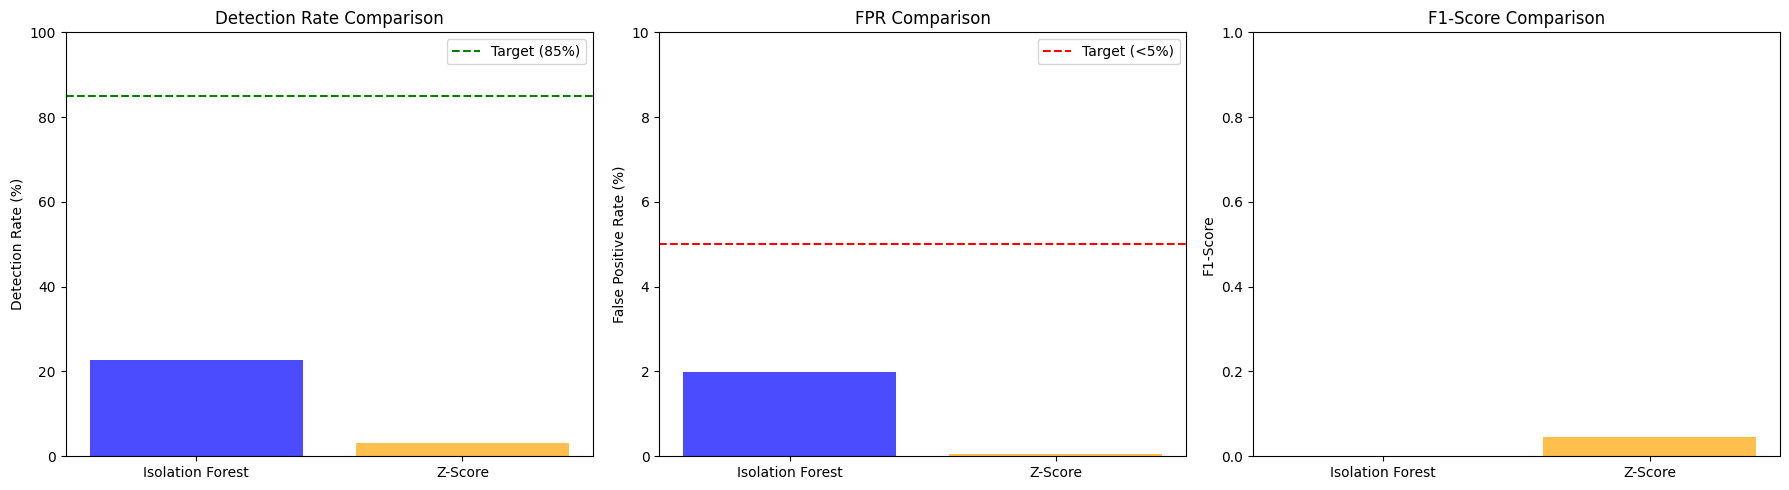

In [47]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Detection Rate
axes[0].bar(comparison['Model'], comparison['Detection Rate (%)'], 
           color=['blue', 'orange'], alpha=0.7)
axes[0].axhline(85, color='green', linestyle='--', label='Target (85%)')
axes[0].set_ylabel('Detection Rate (%)')
axes[0].set_title('Detection Rate Comparison')
axes[0].legend()
axes[0].set_ylim([0, 100])

# False Positive Rate
axes[1].bar(comparison['Model'], comparison['False Positive Rate (%)'],
           color=['blue', 'orange'], alpha=0.7)
axes[1].axhline(5, color='red', linestyle='--', label='Target (<5%)')
axes[1].set_ylabel('False Positive Rate (%)')
axes[1].set_title('FPR Comparison')
axes[1].legend()
axes[1].set_ylim([0, 10])

# F1-Score
axes[2].bar(comparison['Model'], comparison['F1-Score'],
           color=['blue', 'orange'], alpha=0.7)
axes[2].set_ylabel('F1-Score')
axes[2].set_title('F1-Score Comparison')
axes[2].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('C:/Users/parth/Market-Anomaly-Detection-System/reports/figures/unsupervised_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### ROC and PR Curves

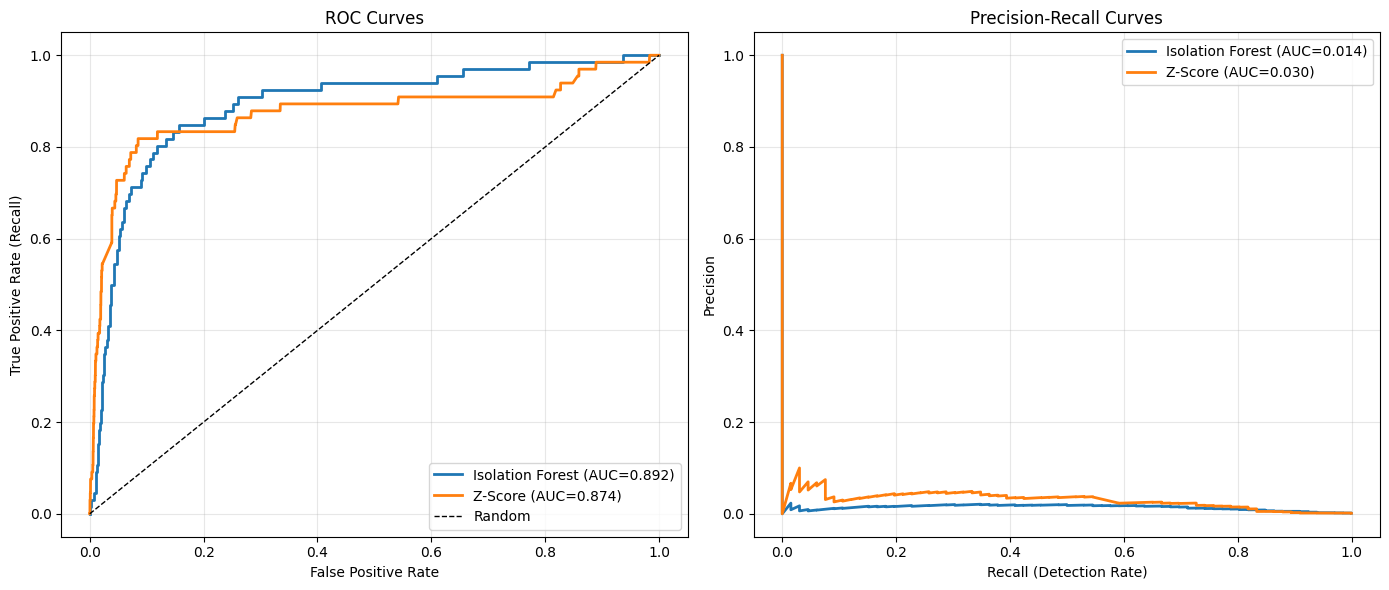

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curves
fpr_iso, tpr_iso, _ = roc_curve(y_test, test_scores_norm)
fpr_z, tpr_z, _ = roc_curve(y_test, test_z_norm)

axes[0].plot(fpr_iso, tpr_iso, label=f'Isolation Forest (AUC={roc_auc_score(y_test, test_scores_norm):.3f})', linewidth=2)
axes[0].plot(fpr_z, tpr_z, label=f'Z-Score (AUC={roc_auc_score(y_test, test_z_norm):.3f})', linewidth=2)
axes[0].plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curves
prec_iso, rec_iso, _ = precision_recall_curve(y_test, test_scores_norm)
prec_z, rec_z, _ = precision_recall_curve(y_test, test_z_norm)

axes[1].plot(rec_iso, prec_iso, label=f'Isolation Forest (AUC={auc(rec_iso, prec_iso):.3f})', linewidth=2)
axes[1].plot(rec_z, prec_z, label=f'Z-Score (AUC={auc(rec_z, prec_z):.3f})', linewidth=2)
axes[1].set_xlabel('Recall (Detection Rate)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/parth/Market-Anomaly-Detection-System/reports/figures/unsupervised_roc_pr_curves.png', dpi=300, bbox_inches='tight')
plt.show()

### Save Models and Results

In [49]:
# Save Isolation Forest model
with open('C:/Users/parth/Market-Anomaly-Detection-System/models/isolation_forest.pkl', 'wb') as f:
    pickle.dump(iso_forest, f)
print("Isolation Forest saved: models/isolation_forest.pkl")

Isolation Forest saved: models/isolation_forest.pkl


In [50]:
# Save thresholds and parameters
model_info = {
    'isolation_forest': {
        'best_threshold': float(best_threshold),
        'contamination': float(contamination),
        'n_estimators': 100,
        'detection_rate': float(detection_rate),
        'fpr': float(fpr),
        'precision': float(precision),
        'f1_score': float(f1),
        'roc_auc': float(roc_auc),
        'pr_auc': float(pr_auc)
    },
    'z_score': {
        'best_threshold': float(best_z_threshold),
        'detection_rate': float(z_detection_rate),
        'fpr': float(z_fpr)
    },
    'training_stats': {
        'train_mean': train_mean.tolist(),
        'train_std': train_std.tolist()
    },
    'timestamp': datetime.now().isoformat()
}

with open('C:/Users/parth/Market-Anomaly-Detection-System/models/unsupervised_models_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)
print("Model info saved: models/unsupervised_models_info.json")

Model info saved: models/unsupervised_models_info.json
